In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
cngen = pd.read_csv("CN General Catalogues.csv", date_format='%Y-%m-%d')
cncpi = pd.read_csv("CN CPI index.csv", date_format='%Y-%m-%d')
cnspe = pd.read_csv("CN Specific Catalogues.csv", date_format='%Y-%m-%d')

cngen['Date'] = pd.to_datetime(cngen['Date'])
cncpi['Date'] = pd.to_datetime(cncpi['Date'])

In [3]:
genlunar = cngen[
    (cngen['Date'].dt.month.isin([1, 2])) &
    (cngen['Retail Sales (CNY 100M)'].isna())
]

genlunar = genlunar[['Date', 'Retail Sales (CNY 100M)', 'Retail Sales Tot Per Annu (CNY 100M)']]

genlunar['Retail Sales Tot Per Annu (CNY 100M)'] = genlunar['Retail Sales Tot Per Annu (CNY 100M)'].ffill()

days_in_month = genlunar['Date'].dt.days_in_month
jan1 = pd.to_datetime(genlunar['Date'].dt.year.astype(str) + '-01-01')
mar1 = pd.to_datetime(genlunar['Date'].dt.year.astype(str) + '-03-01')
days_janfeb = (mar1 - jan1).dt.days
genlunar['Retail Sales (CNY 100M)'] = (
    days_in_month / days_janfeb *
    genlunar['Retail Sales Tot Per Annu (CNY 100M)']
)

genlunar = genlunar[['Date', 'Retail Sales (CNY 100M)']]

In [4]:
cnadj = cngen.merge(genlunar, on = 'Date', how = 'left', suffixes=('', '_y'))
cnadj['Retail Sales (CNY 100M)'] = cnadj['Retail Sales (CNY 100M)'].combine_first(cnadj['Retail Sales (CNY 100M)_y'])
cnadj = cnadj.drop(columns=['Retail Sales (CNY 100M)_y'])

cnadj = cnadj[['Date', 'Retail Sales (CNY 100M)']].merge(cncpi, on = 'Date')
cnadj['Adjusted Retail Sales (CNY 100M)'] = cnadj['Retail Sales (CNY 100M)'] / cnadj['CPIIndex']

In [5]:
cnadj = cnadj.set_index('Date')
cnadj.head()

,Retail Sales (CNY 100M),CPIIndex,CPIIndex excluding groceries,CPIIndex of Consumer Goods,CPIIndex of Services,CPIIndex of Apparel,CPIIndex excluding Groceries and Energy,Adjusted Retail Sales (CNY 100M)
Date,,,,,,,,
2026-04-01,37246.50000,103.296801,105.067607,102.661624,104.006105,105.706460,104.058064,360.577479
2026-03-01,41616.00000,102.990033,104.349758,102.550862,103.567920,105.970536,103.772638,404.077936
2026-02-01,40851.00339,103.742173,104.602298,102.852579,104.763621,105.559799,104.486188,393.774317
2026-01-01,45227.89661,102.803979,103.786667,102.118296,103.617240,105.646472,103.766955,439.943054
2025-12-01,45135.90000,102.661950,103.592800,102.066360,103.279745,105.872820,103.578025,439.655587


In [6]:
cncpi = cncpi.set_index('Date')
cncpi.head()

,CPIIndex,CPIIndex excluding groceries,CPIIndex of Consumer Goods,CPIIndex of Services,CPIIndex of Apparel,CPIIndex excluding Groceries and Energy
Date,,,,,,
2026-04-01,103.296801,105.067607,102.661624,104.006105,105.706460,104.058064
2026-03-01,102.990033,104.349758,102.550862,103.567920,105.970536,103.772638
2026-02-01,103.742173,104.602298,102.852579,104.763621,105.559799,104.486188
2026-01-01,102.803979,103.786667,102.118296,103.617240,105.646472,103.766955
2025-12-01,102.661950,103.592800,102.066360,103.279745,105.872820,103.578025


In [7]:
'''def shade_periods(
    axs, 
    periods = [
    ('2007-07-01', '2009-06-30'),
    ('2020-03-01', '2022-12-31')], 
    color='lightgrey', 
    alpha=0.3):
    for ax in axs:
        for start, end in periods:
            ax.axvspan(start, end,
                       color=color, alpha=alpha)'''

"def shade_periods(\n    axs, \n    periods = [\n    ('2007-07-01', '2009-06-30'),\n    ('2020-03-01', '2022-12-31')], \n    color='lightgrey', \n    alpha=0.3):\n    for ax in axs:\n        for start, end in periods:\n            ax.axvspan(start, end,\n                       color=color, alpha=alpha)"

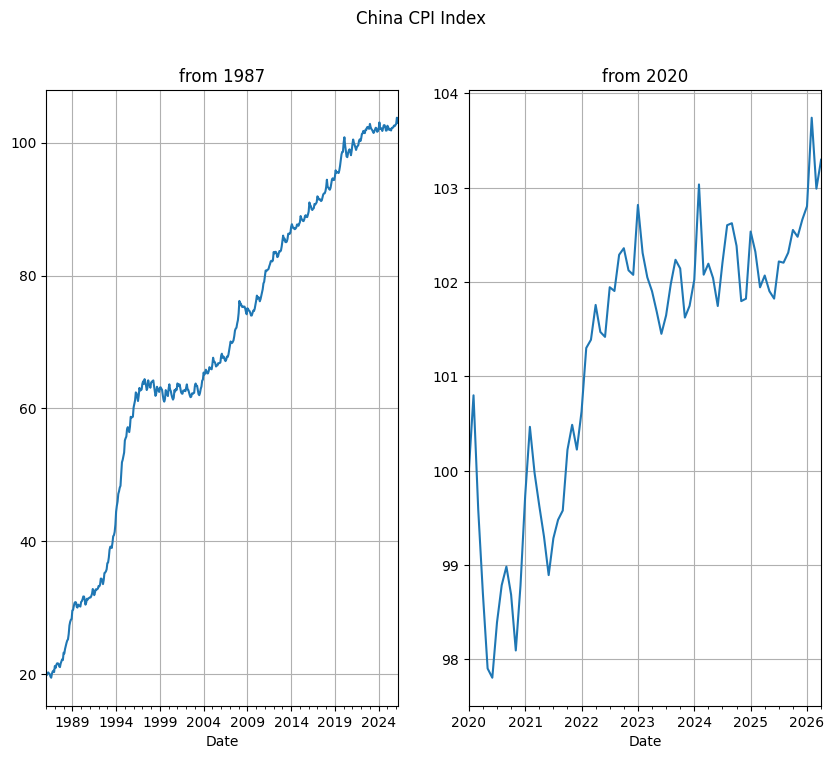

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(10,8))

cncpi['CPIIndex'].plot(ax=axs[0], title="from 1987")
cncpi[cncpi.index.year>=2020]['CPIIndex'].plot(ax=axs[1], title="from 2020")

#fig.autofmt_xdate()
for ax in axs:
    ax.grid(which='major')
plt.suptitle("China CPI Index")
plt.show()

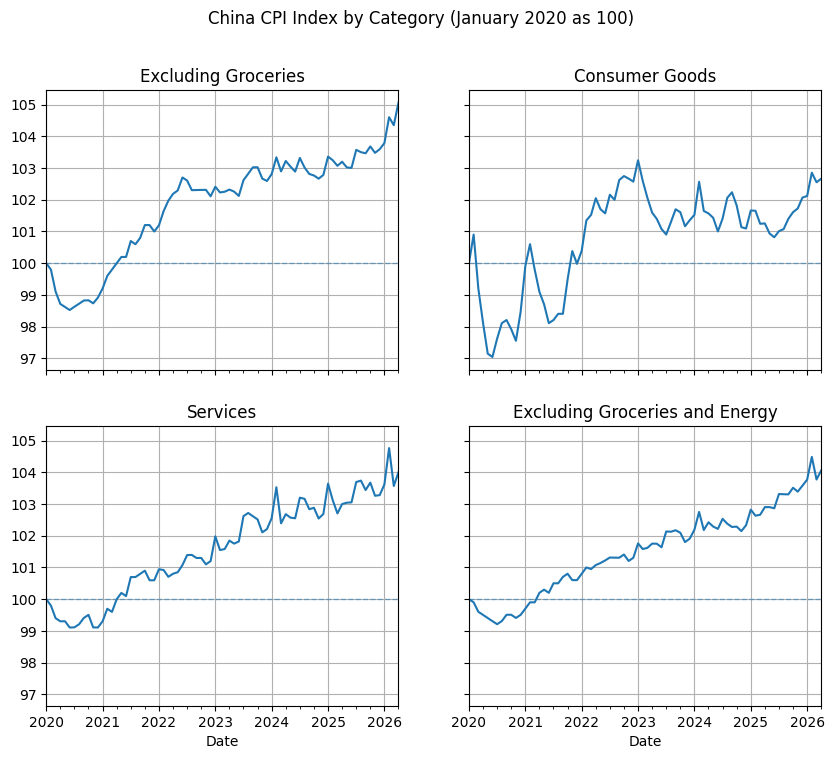

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(10,8), sharey=True, sharex=True)

cncpi['CPIIndex excluding groceries'].dropna().plot(ax=axs[0 ,0], title="Excluding Groceries")
cncpi['CPIIndex of Consumer Goods'].dropna().plot(ax=axs[0, 1],title="Consumer Goods")
cncpi['CPIIndex of Services'].dropna().plot(ax=axs[1, 0], title="Services")
cncpi['CPIIndex excluding Groceries and Energy'].dropna().plot(ax=axs[1, 1], title="Excluding Groceries and Energy")

for ax in axs.flat:
    ax.axhline(100, linewidth=1, linestyle='--', alpha=0.5)
    ax.grid(which='major')

plt.suptitle("China CPI Index by Category (January 2020 as 100)")
plt.show()

In [10]:
# STL Charts generation
def STL_charts(series, title): 
    from statsmodels.tsa.seasonal import STL
    stl = STL(series, seasonal = 13)
    result = stl.fit()

    fig, axs = plt.subplots(3, 1, figsize=(10,8),sharex=True)

    axs[0].plot(result.observed, color='grey', label='Observed')
    axs[0].plot(result.trend, color='goldenrod', alpha=0.5, label='Trend')
    axs[0].legend()
    axs[0].set_title('Observed and Trend')

    axs[1].plot(result.seasonal, color='darkslategrey')
    axs[1].axhline(y=0, linestyle='--', color='darkslategrey', alpha=0.5)
    axs[1].set_title('Seasonal')

    axs[2].plot(result.resid, color='rebeccapurple')
    axs[2].axhline(y=0, linestyle='--', color='rebeccapurple', alpha=0.5)
    axs[2].set_title('Residual')

    plt.suptitle(f'STL Decomposition of {title}', fontsize=16)
    plt.tight_layout()
    fig.autofmt_xdate()

    plt.show()

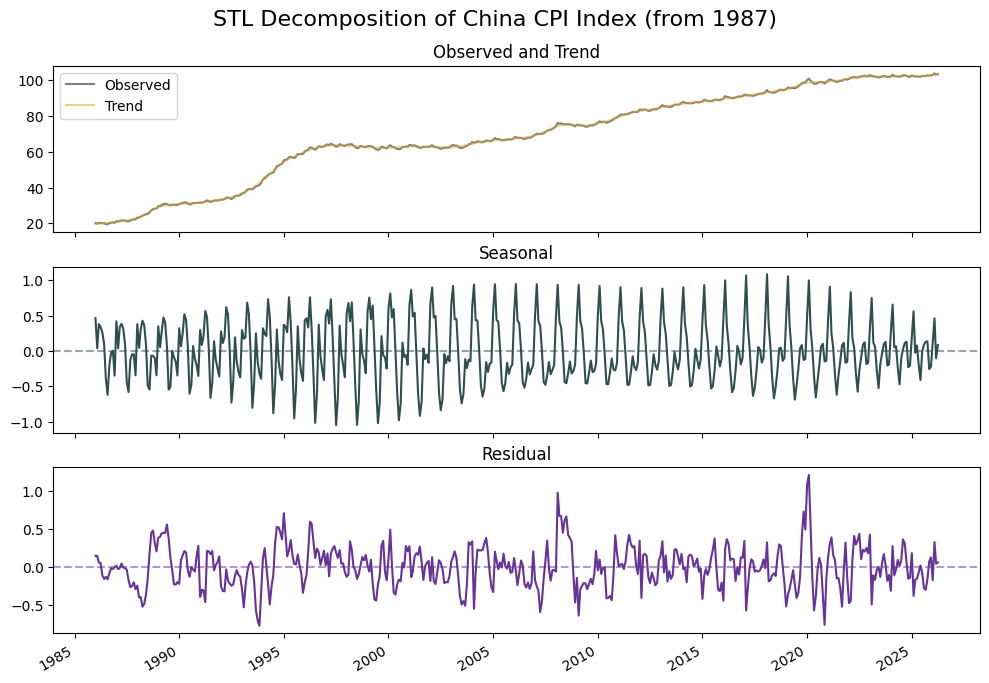

In [11]:
STL_charts(cncpi['CPIIndex'], "China CPI Index (from 1987)")

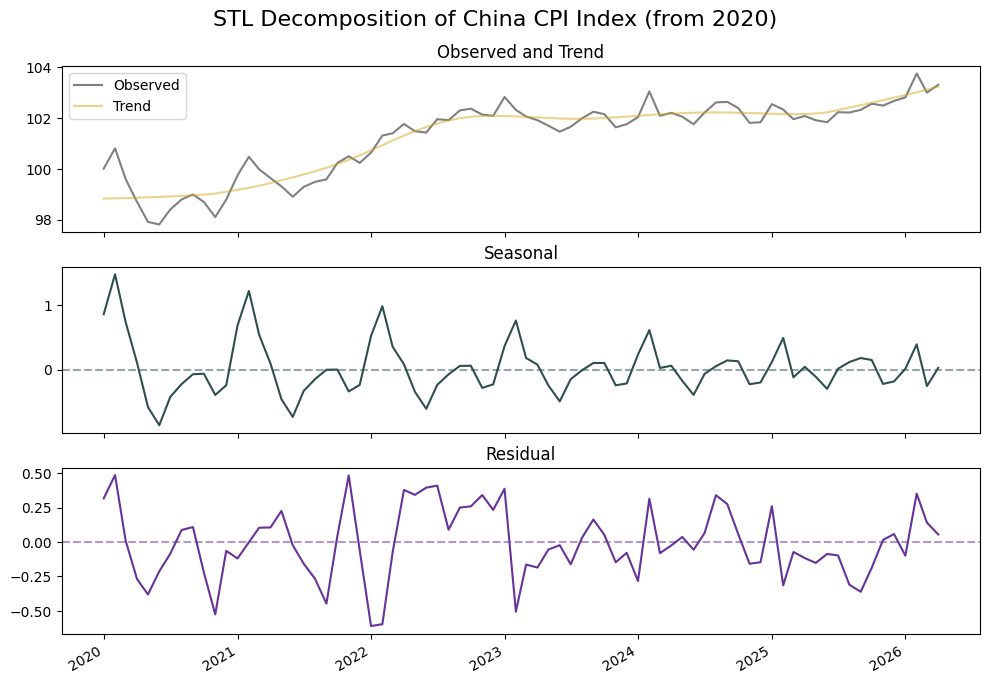

In [12]:
STL_charts(cncpi[cncpi.index.year>=2020]['CPIIndex'], "China CPI Index (from 2020)")

In [13]:
from statsmodels.tsa.filters.hp_filter import hpfilter

def HP_chart(series, title, lamb=129600):
    cycle, trend = hpfilter(series, lamb=lamb)

    decomp = pd.DataFrame(series)
    decomp['cycle'] = cycle
    decomp['trend'] = trend

    fig, axs = plt.subplots(2, 1, figsize=(10,8),sharex=True)

    axs[0].plot(decomp.iloc[:, 0], label='CPI Index')
    axs[0].plot(decomp['trend'], label='Trend')
    axs[0].legend()

    axs[1].plot(decomp['cycle'], label='Cycle')
    axs[1].axhline(y=0, linestyle='--', alpha=0.5)
    axs[1].legend()

    plt.suptitle(f'Hodrick–Prescott Filter of {title}')
    plt.show()

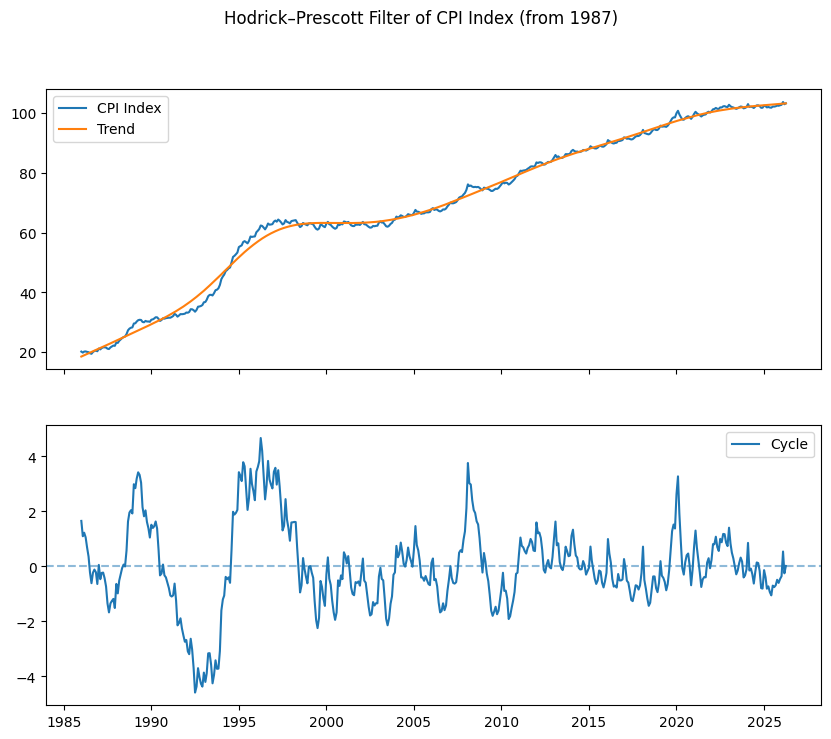

In [14]:
HP_chart(cncpi['CPIIndex'], 'CPI Index (from 1987)')

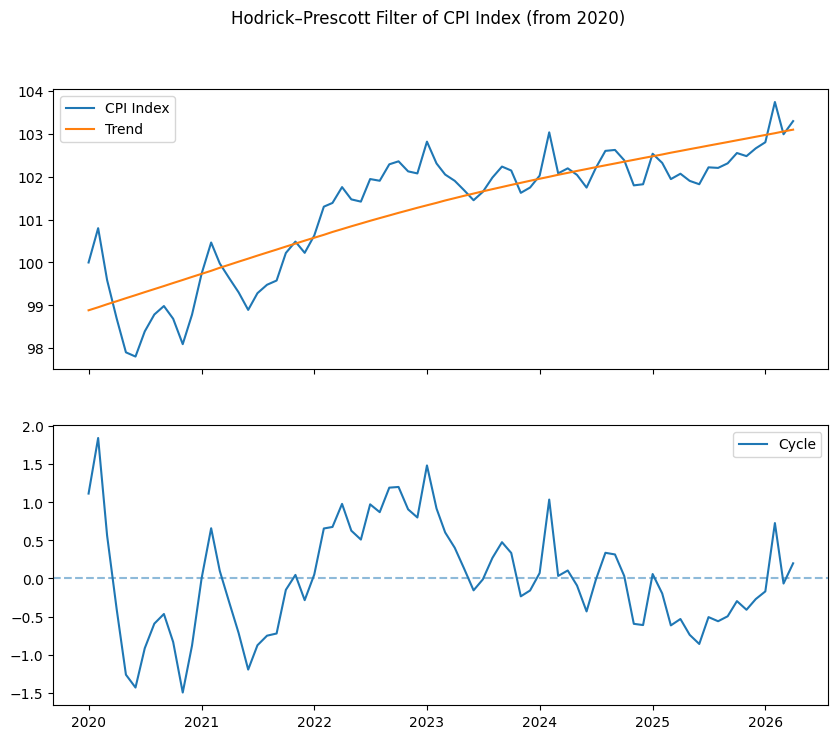

In [15]:
HP_chart(cncpi[cncpi.index.year>=2020]['CPIIndex'], 'CPI Index (from 2020)')

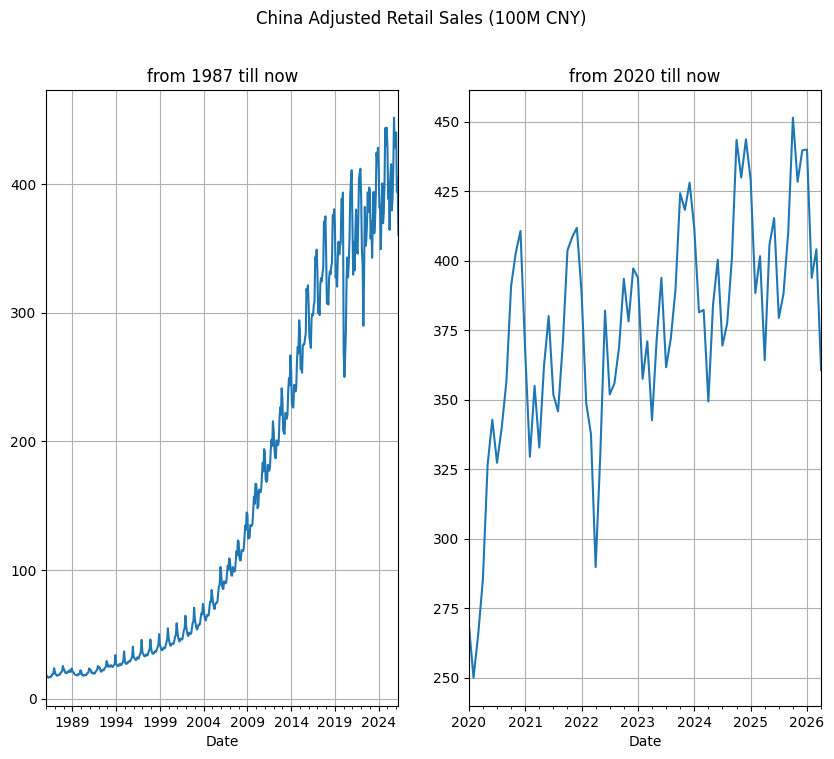

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(10,8))

cnadj['Adjusted Retail Sales (CNY 100M)'].plot(ax=axs[0], title="from 1987 till now")
cnadj[cnadj.index.year>=2020]['Adjusted Retail Sales (CNY 100M)'].plot(ax=axs[1], title="from 2020 till now")

for ax in axs.flat:
    ax.grid(which='major')

plt.suptitle("China Adjusted Retail Sales (100M CNY)")
plt.show()

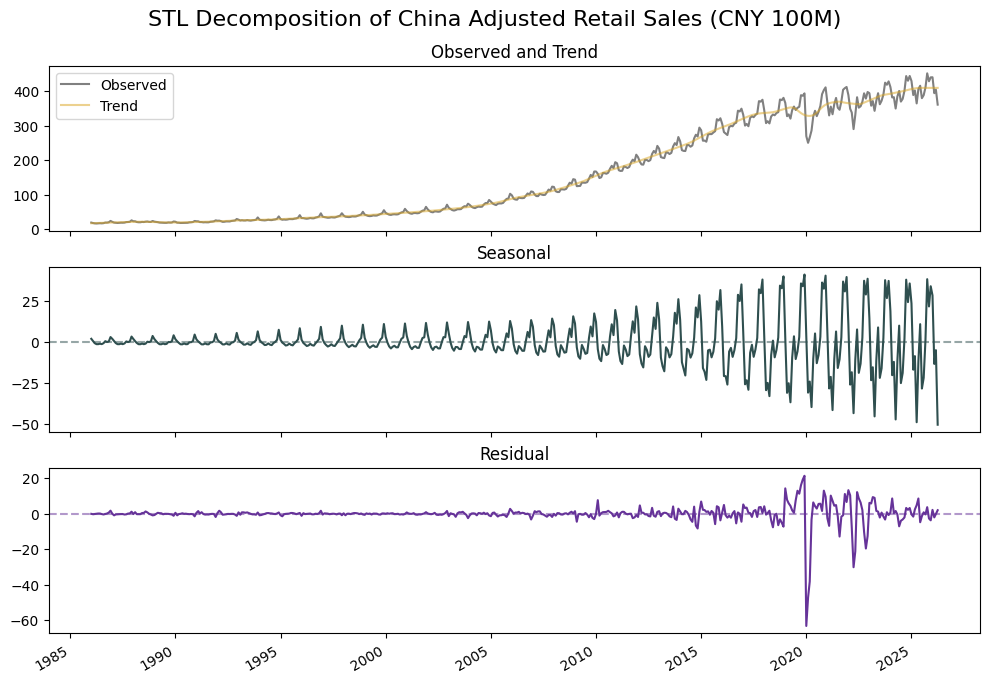

In [17]:
STL_charts(cnadj['Adjusted Retail Sales (CNY 100M)'], "China Adjusted Retail Sales (CNY 100M)")

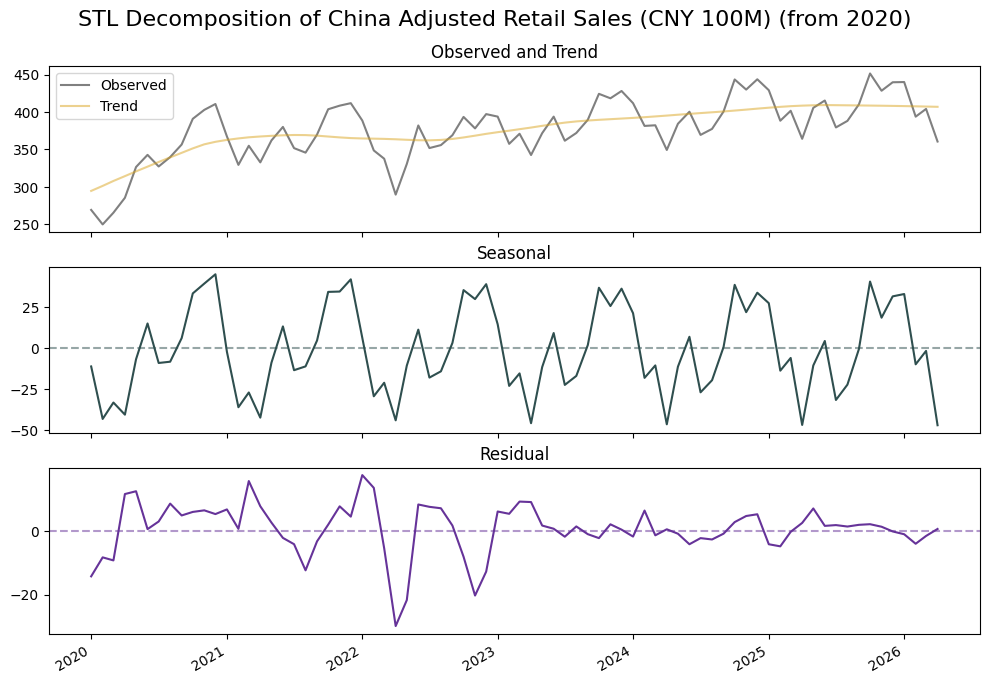

In [18]:
STL_charts(cnadj[cnadj.index.year>=2020]['Adjusted Retail Sales (CNY 100M)'], "China Adjusted Retail Sales (CNY 100M) (from 2020)")

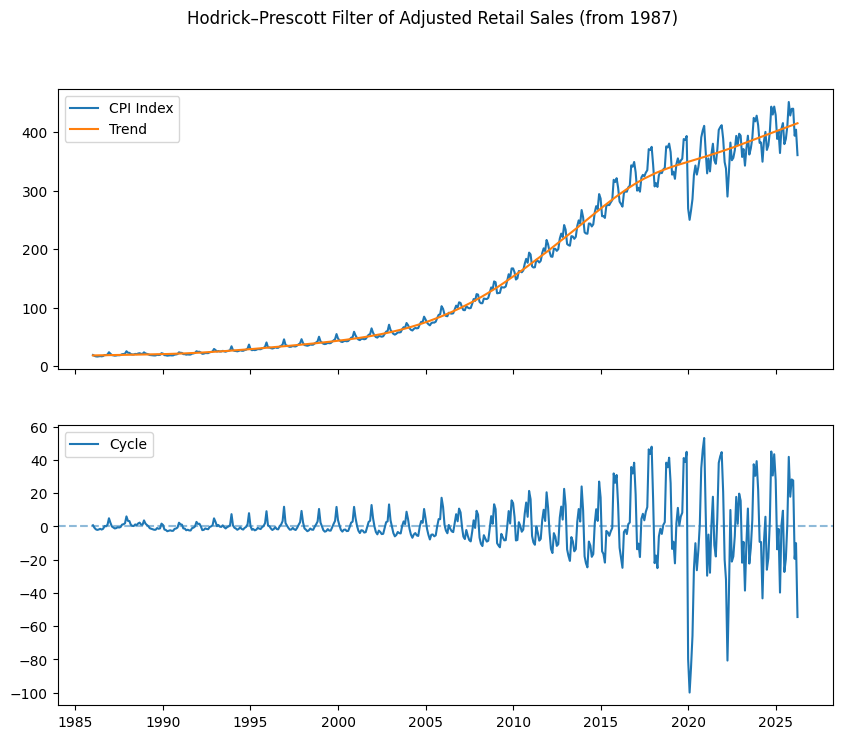

In [19]:
HP_chart(cnadj['Adjusted Retail Sales (CNY 100M)'], 'Adjusted Retail Sales (from 1987)')

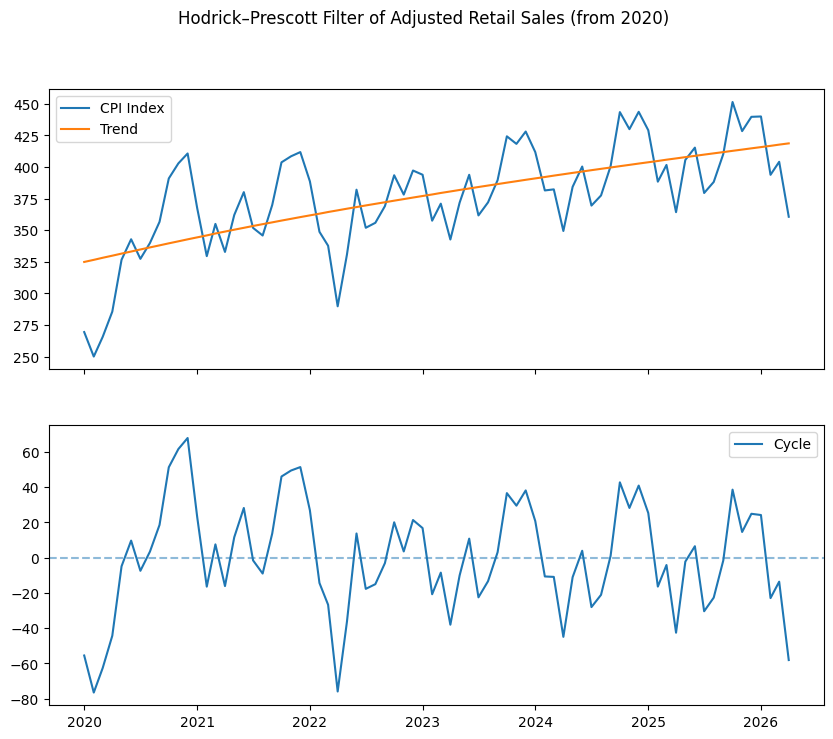

In [20]:
HP_chart(cnadj[cnadj.index.year>=2020]['Adjusted Retail Sales (CNY 100M)'], 'Adjusted Retail Sales (from 2020)')

Text(0.5, 1.0, 'Autocorrelation of CPI Index')

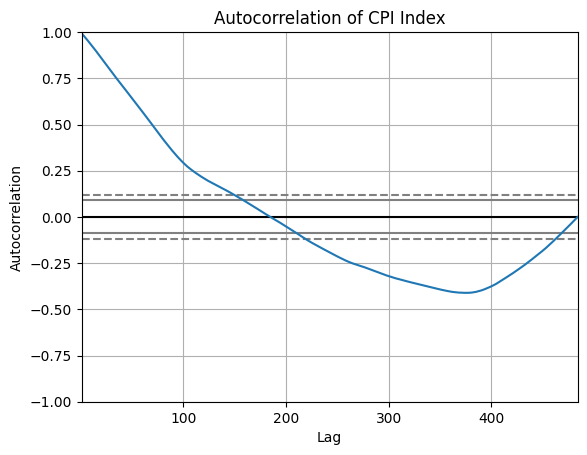

In [21]:
pd.plotting.autocorrelation_plot(cncpi['CPIIndex'])
plt.title("Autocorrelation of CPI Index")

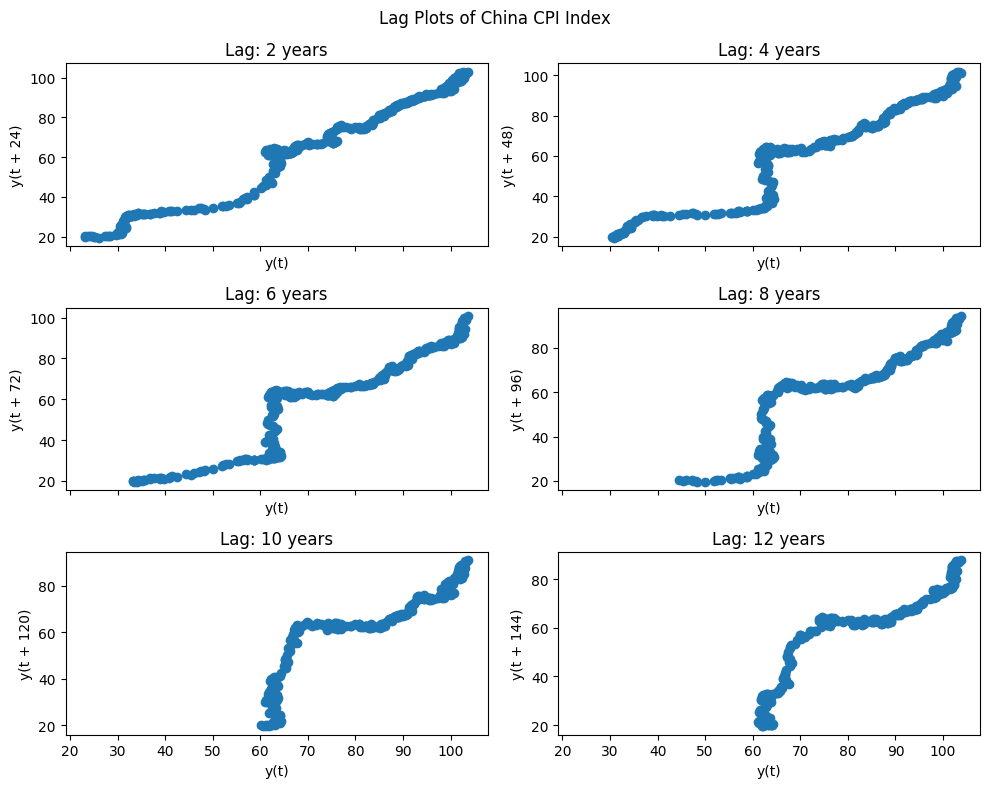

In [22]:
fig, axs = plt.subplots(3, 2, figsize=(10,8),sharex=True)
axs_flat = axs.flatten()

for i in range(6):
    pd.plotting.lag_plot(cncpi['CPIIndex'], lag = 24 * (i+1), ax = axs_flat[i])
    axs_flat[i].title.set_text(f"Lag: {(i+1)*2} years")

plt.suptitle("Lag Plots of China CPI Index")
plt.tight_layout()
plt.show()

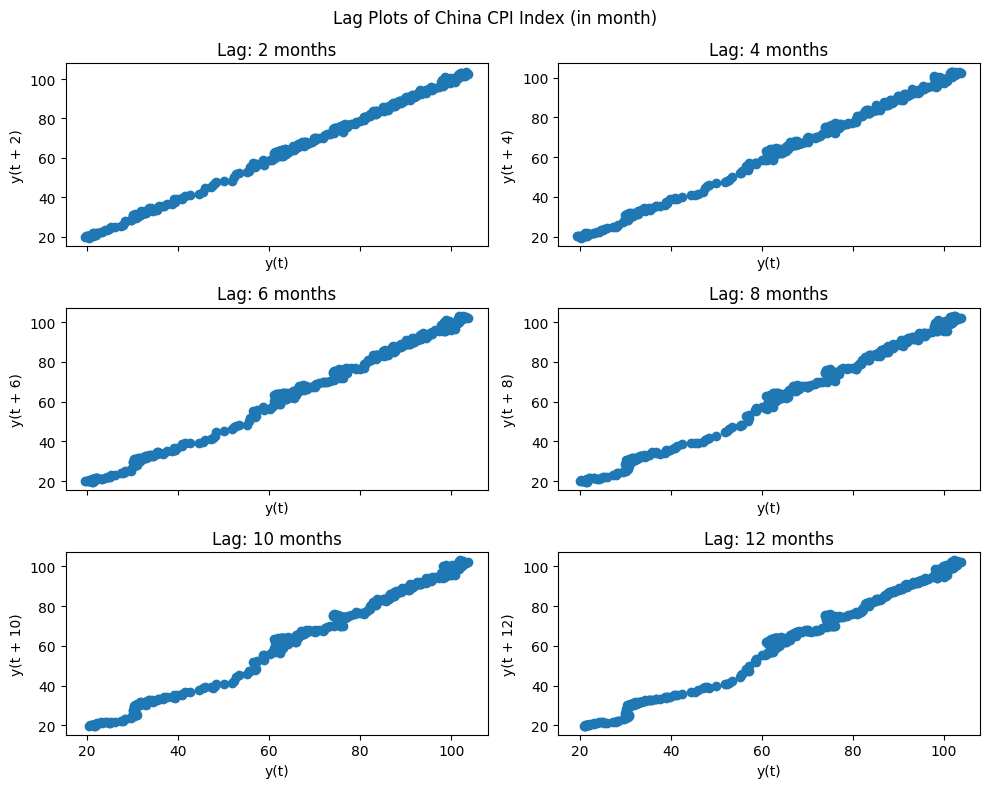

In [23]:
fig, axs = plt.subplots(3, 2, figsize=(10,8),sharex=True)
axs_flat = axs.flatten()

for i in range(6):
    pd.plotting.lag_plot(cncpi['CPIIndex'], lag = 2 * (i+1), ax = axs_flat[i])
    axs_flat[i].title.set_text(f"Lag: {(i+1)*2} months")

plt.suptitle("Lag Plots of China CPI Index (in month)")
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Autocorrelation of Adjusted Retail Sales')

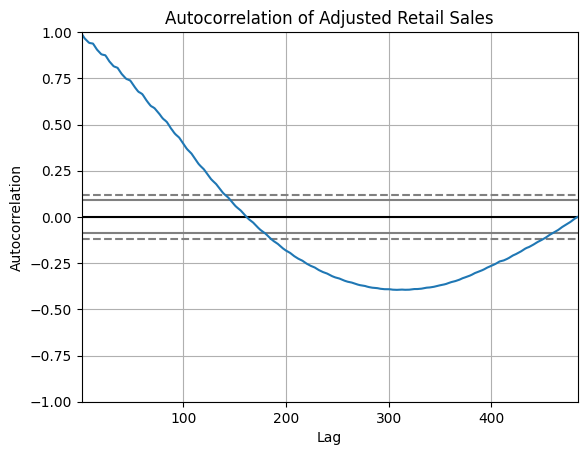

In [24]:
pd.plotting.autocorrelation_plot(cnadj['Adjusted Retail Sales (CNY 100M)'])
plt.title("Autocorrelation of Adjusted Retail Sales")

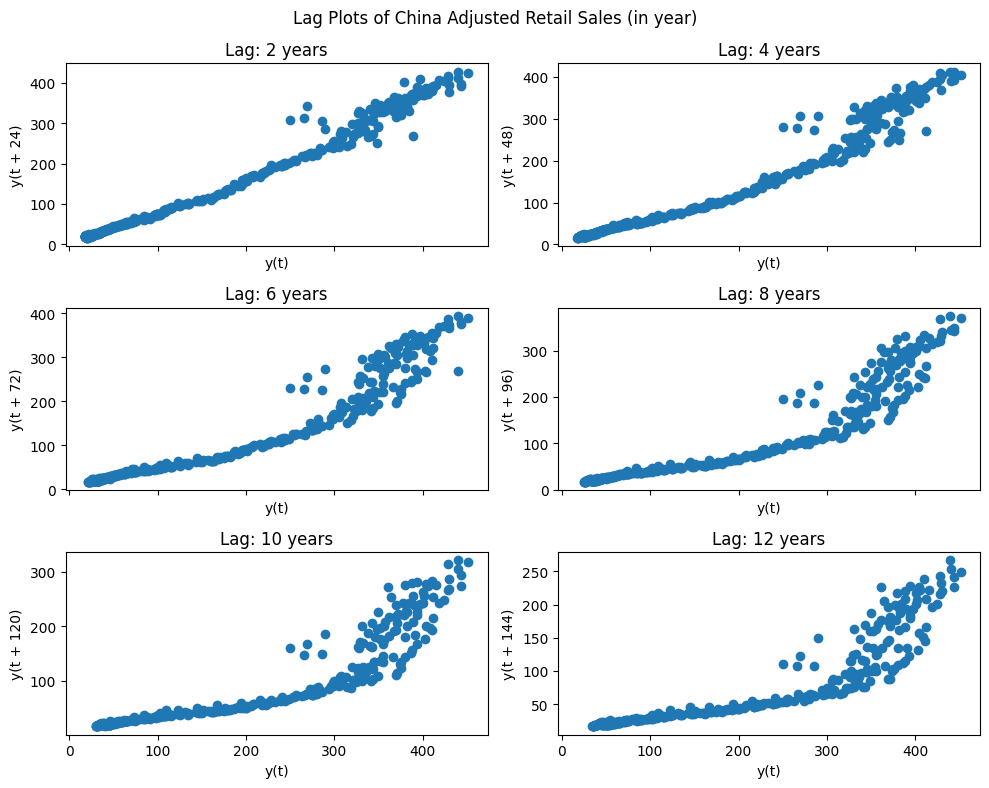

In [25]:
fig, axs = plt.subplots(3, 2, figsize=(10,8),sharex=True)
axs_flat = axs.flatten()

for i in range(6):
    pd.plotting.lag_plot(cnadj['Adjusted Retail Sales (CNY 100M)'], lag = 24 * (i+1), ax = axs_flat[i])
    axs_flat[i].title.set_text(f"Lag: {(i+1)*2} years")

plt.suptitle("Lag Plots of China Adjusted Retail Sales (in year)")
plt.tight_layout()
plt.show()

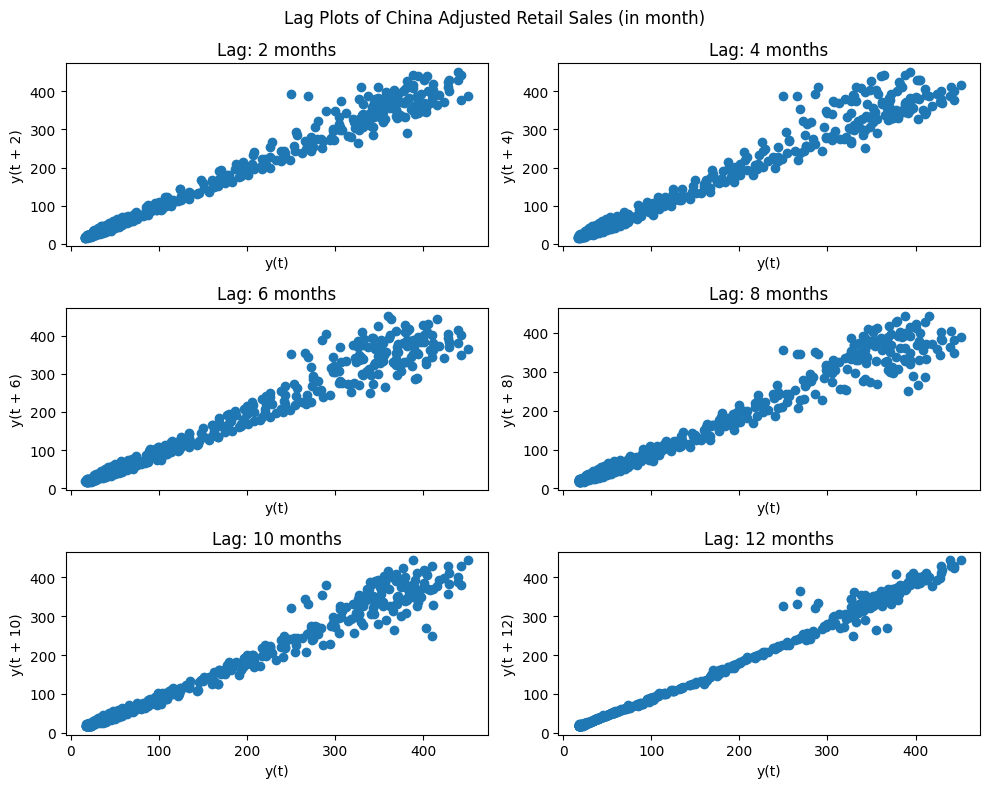

In [26]:
fig, axs = plt.subplots(3, 2, figsize=(10,8),sharex=True)
axs_flat = axs.flatten()

for i in range(6):
    pd.plotting.lag_plot(cnadj['Adjusted Retail Sales (CNY 100M)'], lag = 2 * (i+1), ax = axs_flat[i])
    axs_flat[i].title.set_text(f"Lag: {(i+1)*2} months")

plt.suptitle("Lag Plots of China Adjusted Retail Sales (in month)")
plt.tight_layout()
plt.show()

In [27]:
cn_ppi_input = pd.read_csv('CN PPI Input Index.csv')
cn_ppi_output = pd.read_csv('CN PPI Output Index General.csv')
cn_ppi_input['Date'] = pd.to_datetime(cn_ppi_input['Date'])
cn_ppi_output['Date'] = pd.to_datetime(cn_ppi_output['Date'])
cn_ppi_output = cn_ppi_output[['Date', 'PPI Output Index']]

In [28]:
cn_ppi = cn_ppi_input[['Date', 'PPI Input Index']]
cn_ppi = cn_ppi.merge(cn_ppi_output, on='Date', how='outer')
cn_ppi = cn_ppi.set_index('Date')
cn_ppi = cn_ppi.join(cncpi['CPIIndex'])

In [29]:
cn_ppi['Diff (O-I)'] = cn_ppi['PPI Output Index'] - cn_ppi['PPI Input Index']
cn_ppi['Diff (C-O)'] = cn_ppi['CPIIndex'] - cn_ppi['PPI Output Index']
cn_ppi['Diff (C-I)'] = cn_ppi['CPIIndex'] - cn_ppi['PPI Input Index']
cn_ppi.head()

,PPI Input Index,PPI Output Index,CPIIndex,Diff (O-I),Diff (C-O),Diff (C-I)
Date,,,,,,
1992-01-01,NaN,45.171861,33.293287,NaN,-11.878575,NaN
1992-02-01,NaN,46.690880,33.225153,NaN,-13.465727,NaN
1992-03-01,NaN,46.108820,33.475334,NaN,-12.633486,NaN
1992-04-01,NaN,46.457486,34.395959,NaN,-12.061527,NaN
1992-05-01,NaN,46.663907,34.371909,NaN,-12.291998,NaN


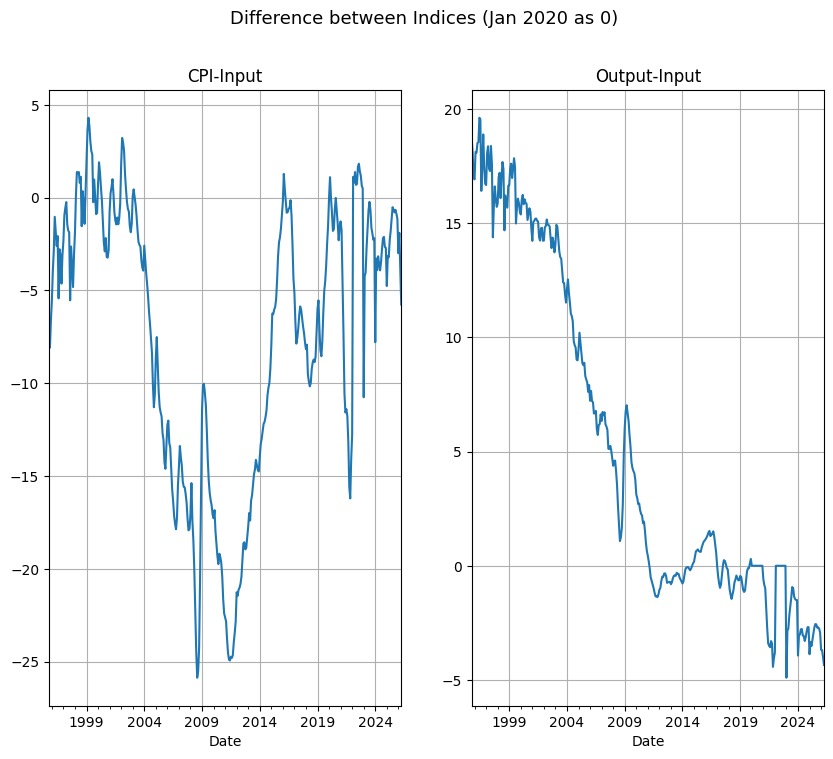

In [30]:
fig, axs = plt.subplots(1, 2, figsize=(10,8))

cn_ppi['Diff (C-I)'].dropna().plot(ax=axs[0], title='CPI-Input', grid=True)
cn_ppi['Diff (O-I)'].dropna().plot(ax=axs[1], title='Output-Input', grid=True)

plt.suptitle("Difference between Indices (Jan 2020 as 0)", fontsize=13)
plt.show()

<Axes: title={'center': 'CPI-PPI Output'}, xlabel='Date'>

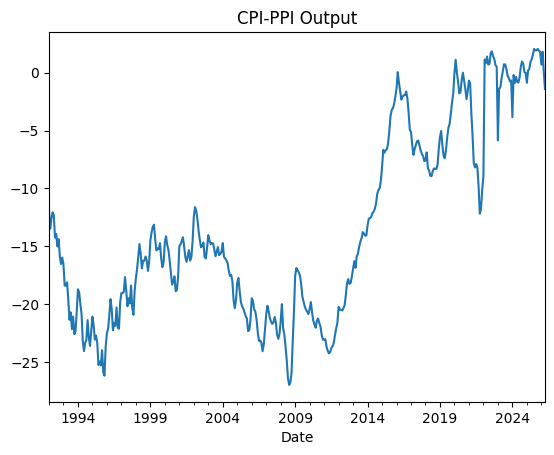

In [31]:
cn_ppi['Diff (C-O)'].plot(title='CPI-PPI Output')